<a href="https://colab.research.google.com/github/elizadunphy/irish-hospital-waiting-list-analysis/blob/main/health_waiting_list_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Irish Hospital Waiting List Analysis

This project analyses Irish hospital outpatient waiting list data to examine patient waiting times across hospitals.

The dataset includes the number of patients waiting in different time bands (0–6 months, 6–12 months, 12–18 months, and 18+ months), broken down by hospital and patient type (Adult/Child).

The analysis focuses on:
- Distribution of waiting lists across hospitals  
- Long waiting times (18+ months)  
- Differences between Adult and Child patients  
- Trends in waiting lists over time

In [74]:
# Import libraries for data analysis and visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')

# Define colour scheme (used in all charts)
line_colour = '#264653'
fill_colour = '#2a9d8f'
bar_colour = '#2a9d8f'

##Load Dataset

The dataset was loaded into the notebook and reviewed to confirm that it was imported correctly.

In [15]:
# Load dataset and preview first rows

file_name = 'OpenData_OPNational01_2025.csv'
df = pd.read_csv(file_name)

df.head()

,ArchiveDate,Adult_Child,HospitalName,0-6 Months,6-12 Months,12-18 Months,18 Months +,Total
0,30/01/2025,Adult,Bantry General Hospital,593,116,0,0,709
1,30/01/2025,Adult,Beaumont Hospital,"25,335","12,493","2,601",379,"40,807"
2,30/01/2025,Adult,Cavan General Hospital,"3,976","1,305",300,11,"5,592"
3,30/01/2025,Adult,Connolly Hospital Blanchardstown,"5,543",609,1,0,"6,153"
4,30/01/2025,Adult,Coombe Women and Infants University Hospital,"1,821",617,103,8,"2,549"


## Initial Data Inspection

The dataset was reviewed to understand its structure before cleaning or analysis. This included checking the number of rows and columns, column names, and data types.

In [16]:
# Check dataset dimensions
df.shape

(933, 8)

In [17]:
# View column names
df.columns

Index(['ArchiveDate', 'Adult_Child', 'HospitalName', '0-6 Months',
       '6-12 Months', '12-18 Months', '18 Months +', 'Total'],
      dtype='object')

In [18]:
# Display dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ArchiveDate   933 non-null    object
 1   Adult_Child   933 non-null    object
 2   HospitalName  933 non-null    object
 3   0-6 Months    933 non-null    object
 4   6-12 Months   933 non-null    object
 5   12-18 Months  933 non-null    object
 6   18 Months +   933 non-null    object
 7   Total         933 non-null    object
dtypes: object(8)
memory usage: 58.4+ KB


## Data Quality Checks

The dataset was checked for missing values, duplicate records, and consistency across key fields such as patient type and hospital names.

In [20]:
# Check for missing values
df.isnull().sum()

,0
ArchiveDate,0
Adult_Child,0
HospitalName,0
0-6 Months,0
6-12 Months,0
12-18 Months,0
18 Months +,0
Total,0


In [21]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [55]:
# Check patient type values
df['Adult_Child'].unique()

array(['Adult', 'Child'], dtype=object)

In [23]:
# Count unique hospitals
df['HospitalName'].nunique()

44

In [56]:
# Check date values
df['ArchiveDate'].unique()[:10]

<DatetimeArray>
['2025-01-30 00:00:00', '2025-02-27 00:00:00', '2025-03-27 00:00:00',
 '2025-04-24 00:00:00', '2025-05-29 00:00:00', '2025-06-26 00:00:00',
 '2025-07-31 00:00:00', '2025-08-28 00:00:00', '2025-09-25 00:00:00',
 '2025-10-30 00:00:00']
Length: 10, dtype: datetime64[ns]

## Data Cleaning

The dataset required preparation before analysis. Numeric columns contained formatting (commas) and were stored as text, so these were converted to numeric values. The date column was also converted to a datetime format.

In [57]:
# Convert '0-6 Months' to numeric

df['0-6 Months'] = df['0-6 Months'].astype(str)
df['0-6 Months'] = df['0-6 Months'].str.replace(',', '')
df['0-6 Months'] = df['0-6 Months'].astype(int)

df['0-6 Months'].dtype

dtype('int64')

In [59]:
# Convert waiting time columns to numeric

columns_to_clean = [
    '0-6 Months',
    '6-12 Months',
    '12-18 Months',
    '18 Months +',
    'Total'
]

for col in columns_to_clean:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(',', '')
    df[col] = df[col].astype(int)

df[columns_to_clean].dtypes

,0
0-6 Months,int64
6-12 Months,int64
12-18 Months,int64
18 Months +,int64
Total,int64


In [60]:
# Convert waiting time columns to numeric

columns_to_clean = [
    '0-6 Months',
    '6-12 Months',
    '12-18 Months',
    '18 Months +',
    'Total'
]

for col in columns_to_clean:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(',', '')
    df[col] = df[col].astype(int)

df[columns_to_clean].dtypes

,0
0-6 Months,int64
6-12 Months,int64
12-18 Months,int64
18 Months +,int64
Total,int64


In [62]:
# Convert date column to datetime

df['ArchiveDate'] = pd.to_datetime(df['ArchiveDate'])

df['ArchiveDate'].dtype

dtype('<M8[ns]')

## Exploratory Data Analysis

The cleaned dataset was analysed to explore trends in hospital waiting lists, including total waiting numbers over time and variation across hospitals.

In [31]:
# Total waiting list over time

monthly_total = df.groupby('ArchiveDate')['Total'].sum()

monthly_total

,Total
ArchiveDate,
2025-01-30,569249
2025-02-27,575716
2025-03-27,581736
2025-04-24,584713
2025-05-29,586917
2025-06-26,600390
2025-07-31,614470
2025-08-28,623008
2025-09-25,626521


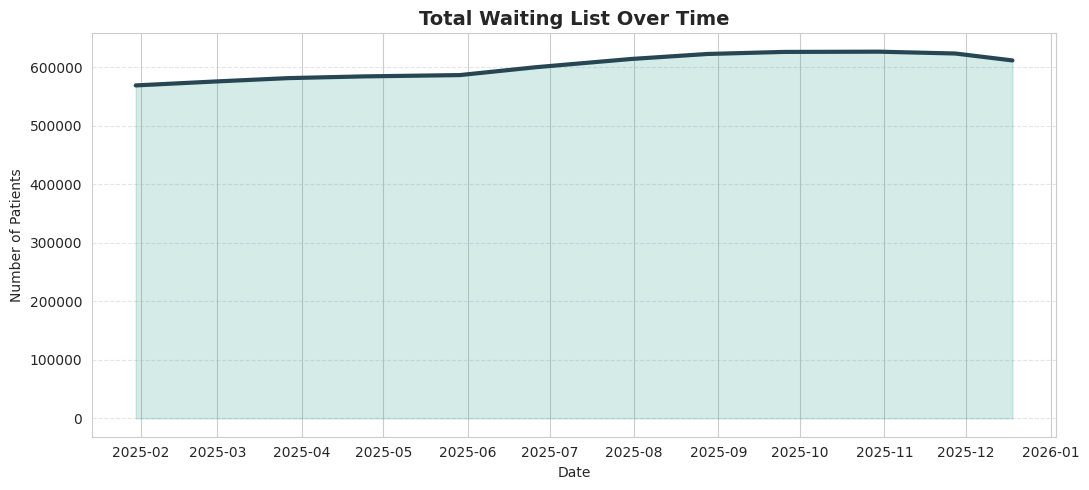

In [75]:
# Plot total waiting list over time

plt.figure(figsize=(11,5))

plt.plot(
    monthly_total,
    linewidth=3,
    color=line_colour
)

plt.fill_between(
    monthly_total.index,
    monthly_total.values,
    color=fill_colour,
    alpha=0.2
)

plt.title('Total Waiting List Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Patients')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Waiting List by Hospital

This section analyses total waiting list volumes across hospitals to identify those with the highest patient numbers.

In [76]:
# Total waiting list by hospital

hospital_totals = df.groupby('HospitalName')['Total'].sum()
hospital_totals = hospital_totals.sort_values(ascending=False)

hospital_totals.head(10)

,Total
HospitalName,
Galway University Hospitals,570745
University Hospital Waterford,555204
Beaumont Hospital,531980
Mater Misericordiae University Hospital,484367
Children's Health Ireland,408805
South Infirmary Victoria University Hospital,402325
St. Vincent's University Hospital,397355
University Hospital Limerick,330440
Tallaght University Hospital,309587


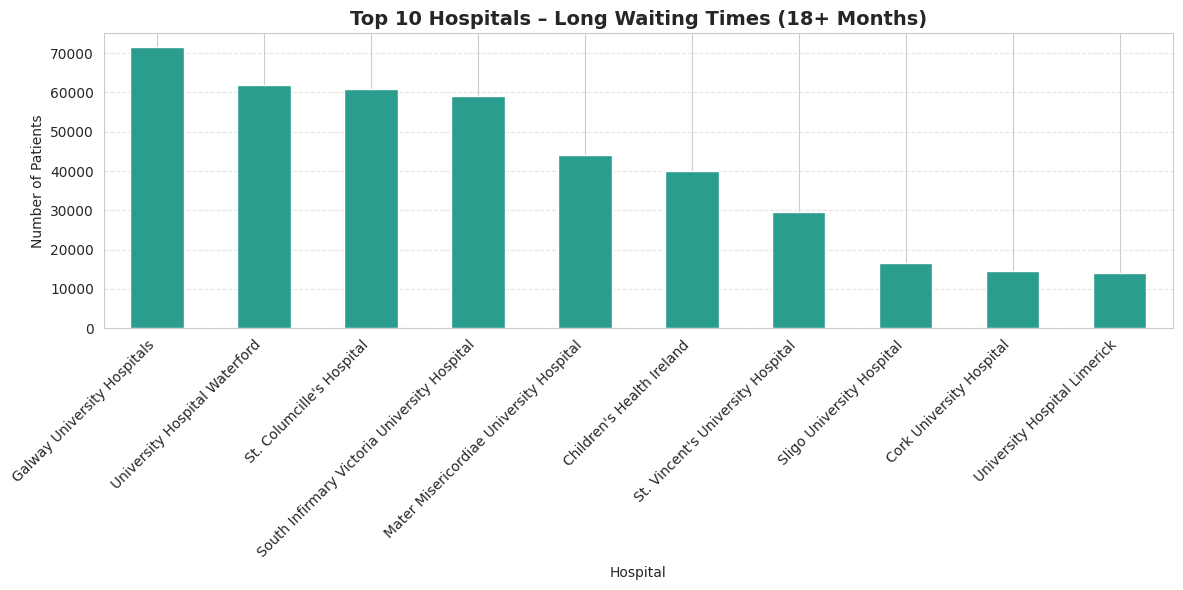

In [78]:
# Plot top 10 hospitals – long waiting times (18+ months)

plt.figure(figsize=(12,6))

long_wait.head(10).plot(
    kind='bar',
    color=bar_colour
)

plt.title('Top 10 Hospitals – Long Waiting Times (18+ Months)', fontsize=14, fontweight='bold')
plt.xlabel('Hospital')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Observation:**

A small number of hospitals account for a large proportion of total waiting list volumes. Galway University Hospitals, University Hospital Waterford, and Beaumont Hospital have the highest patient numbers, with relatively small differences between them.

### Long Waiting Times (18+ Months)

This section examines patients waiting longer than 18 months, which is a key indicator of pressure in the system.

In [66]:
# Total long waiting list (18+ months) by hospital

long_wait = df.groupby('HospitalName')['18 Months +'].sum()
long_wait = long_wait.sort_values(ascending=False)

long_wait_df = long_wait.reset_index()
long_wait_df.columns = ['Hospital Name', 'No. Waiting (18+ Months)']

long_wait_df.head(10)

,Hospital Name,No. Waiting (18+ Months)
0,Galway University Hospitals,71476
1,University Hospital Waterford,61952
2,St. Columcille's Hospital,60978
3,South Infirmary Victoria University Hospital,59019
4,Mater Misericordiae University Hospital,44168
5,Children's Health Ireland,39919
6,St. Vincent's University Hospital,29474
7,Sligo University Hospital,16650
8,Cork University Hospital,14625
9,University Hospital Limerick,13931


**Observation:**

A small number of hospitals account for a large proportion of long waiting times (18+ months). Galway University Hospitals, University Hospital Waterford, and Beaumont Hospital have the highest numbers of patients waiting over 18 months.

### Adult vs Child Waiting Lists

This section compares total waiting list numbers between Adult and Child patients.

In [67]:
# Total waiting list by patient type

adult_child = df.groupby('Adult_Child')['Total'].sum()

adult_child_df = adult_child.reset_index()
adult_child_df.columns = ['Patient Type', 'No. Waiting']

adult_child_df

,Patient Type,No. Waiting
0,Adult,6348857
1,Child,876629


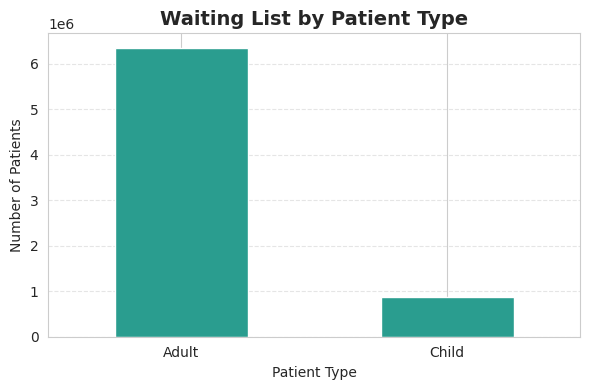

In [79]:
# Plot waiting list by patient type

plt.figure(figsize=(6,4))

adult_child.plot(
    kind='bar',
    color=bar_colour
)

plt.title('Waiting List by Patient Type', fontsize=14, fontweight='bold')
plt.xlabel('Patient Type')
plt.ylabel('Number of Patients')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Observation:**

The waiting list is significantly higher for Adult patients than for Child patients, indicating that demand for adult services accounts for the majority of waiting list pressure.

### Waiting List Over Time

This section examines how the total waiting list changes over time.

In [69]:
# Total waiting list over time

monthly_total = df.groupby('ArchiveDate')['Total'].sum()

monthly_total

,Total
ArchiveDate,
2025-01-30,569249
2025-02-27,575716
2025-03-27,581736
2025-04-24,584713
2025-05-29,586917
2025-06-26,600390
2025-07-31,614470
2025-08-28,623008
2025-09-25,626521


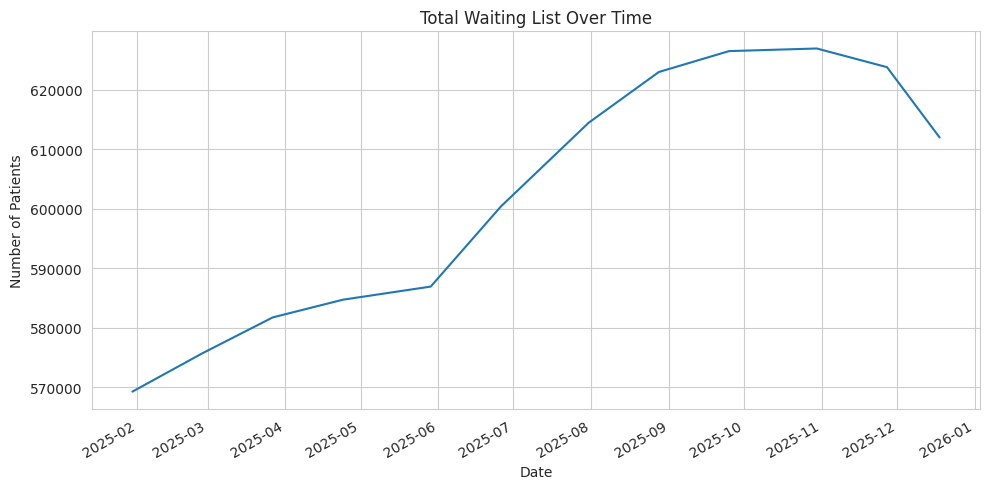

In [70]:
# Plot total waiting list over time

monthly_total.plot(
    figsize=(10,5),
    title='Total Waiting List Over Time'
)

plt.xlabel('Date')
plt.ylabel('Number of Patients')
plt.tight_layout()

plt.show()

**Observation:**

The total waiting list shows an overall increasing trend over time, indicating growing demand and pressure on hospital services.

## Conclusion

This analysis examined Irish hospital outpatient waiting list data across hospitals, patient types, and time.

The results show that a small number of hospitals account for a large proportion of total waiting list volumes and long waiting times (18+ months). Adult patients make up the majority of those waiting, indicating higher demand for adult services.

The waiting list is increasing over time, suggesting growing pressure on hospital capacity and the need for continued monitoring and resource planning.